In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("fm_data.csv")

# Preview
print(df.head())

# Create datetime column
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

# Extract hour
df['hour'] = df['datetime'].dt.hour

# Sort by datetime
df = df.sort_values('datetime').reset_index(drop=True)

# Function to classify time period
def time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# Apply function
df['period'] = df['hour'].apply(time_period)

# Day of week
df['day_of_week'] = df['datetime'].dt.day_name()

# Weekend flag
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

# Final preview
print(df.head())

   Unnamed: 0 Username           Artist                          Track  \
0           0  Babs_05  Isobel Campbell     The Circus Is Leaving Town   
1           1  Babs_05  Isobel Campbell                   Dusty Wreath   
2           2  Babs_05  Isobel Campbell     Honey Child What Can I Do?   
3           3  Babs_05  Isobel Campbell  It's Hard To Kill A Bad Thing   
4           4  Babs_05  Isobel Campbell                Saturday's Gone   

                       Album         Date    Time  
0  Ballad of the Broken Seas  31 Jan 2021   23:36  
1  Ballad of the Broken Seas  31 Jan 2021   23:32  
2  Ballad of the Broken Seas  31 Jan 2021   23:28  
3  Ballad of the Broken Seas  31 Jan 2021   23:25  
4  Ballad of the Broken Seas  31 Jan 2021   23:21  
   Unnamed: 0  Username  Artist                                     Track  \
0       85995    eartle  Eminem  Lose Yourself - From "8 Mile" Soundtrack   
1      256448   Orlenay  Eminem  Lose Yourself - From "8 Mile" Soundtrack   
2      20879

In [15]:
# Choose the most active user
user = 'Babs_05'
user_df = df[df['Username'] == user]

# Count plays per calendar day
ts = user_df.groupby(user_df['datetime'].dt.date).size()

# Convert index to DatetimeIndex so pandas treats it as a proper time series
ts.index = pd.to_datetime(ts.index)

# Ensure every calendar day is present (fills gaps with 0)
ts = ts.asfreq('D').fillna(0)

print(f"Time series length : {len(ts)} days")
print(f"Date range         : {ts.index[0].date()} to {ts.index[-1].date()}")
print(f"Min plays in a day : {int(ts.min())}")
print(f"Max plays in a day : {int(ts.max())}")
print(f"Mean plays per day : {ts.mean():.1f}")
print()
print(ts)

Time series length : 31 days
Date range         : 2021-01-01 to 2021-01-31
Min plays in a day : 33
Max plays in a day : 16302
Mean plays per day : 1086.9

datetime
2021-01-01       52
2021-01-02       45
2021-01-03       52
2021-01-04       33
2021-01-05       42
2021-01-06       36
2021-01-07       39
2021-01-08       40
2021-01-09       94
2021-01-10       83
2021-01-11      102
2021-01-12      100
2021-01-13      116
2021-01-14      101
2021-01-15      123
2021-01-16      149
2021-01-17      180
2021-01-18      160
2021-01-19      245
2021-01-20      136
2021-01-21      226
2021-01-22      366
2021-01-23      433
2021-01-24      237
2021-01-25      540
2021-01-26      886
2021-01-27     1342
2021-01-28     1738
2021-01-29     3816
2021-01-30     5881
2021-01-31    16302
Freq: D, dtype: int64


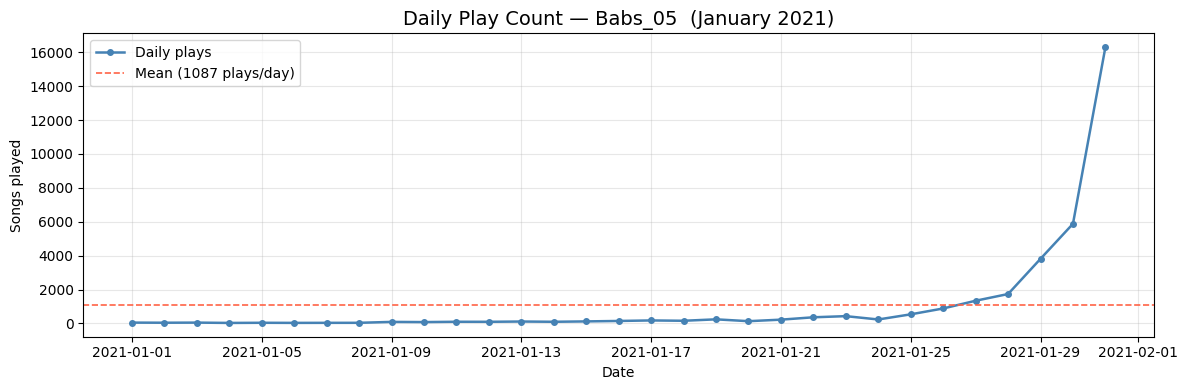

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(ts.index, ts.values, marker='o', linewidth=1.8,
        color='steelblue', markersize=4, label='Daily plays')
ax.axhline(ts.mean(), color='tomato', linestyle='--',
           linewidth=1.2, label=f'Mean ({ts.mean():.0f} plays/day)')

ax.set_title(f'Daily Play Count — {user}  (January 2021)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Songs played')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ── Step 3: ADF Stationarity Test ─────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label='Series'):
    """
    Run the Augmented Dickey-Fuller test and print a clear summary.
    Returns True if the series is stationary, False otherwise.
    """
    result = adfuller(series, autolag='AIC')

    adf_stat  = result[0]   # the test statistic
    p_value   = result[1]   # probability value
    n_lags    = result[2]   # number of lags used
    n_obs     = result[3]   # number of observations
    crit_vals = result[4]   # critical values at 1%, 5%, 10%

    print(f"{'─'*50}")
    print(f" ADF Test — {label}")
    print(f"{'─'*50}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    print(f"  Lags used     : {n_lags}")
    print(f"  Observations  : {n_obs}")
    print(f"  Critical values:")
    for key, val in crit_vals.items():
        print(f"      {key}  ->  {val:.4f}")

    if p_value < 0.05:
        print(f"\n  STATIONARY  (p={p_value:.4f} < 0.05) — no differencing needed.")
        return True
    else:
        print(f"\n  NON-STATIONARY  (p={p_value:.4f} >= 0.05) — differencing required.")
        return False


# --- Test the original series ---
is_stationary = run_adf(ts, label='Original daily play counts')

──────────────────────────────────────────────────
 ADF Test — Original daily play counts
──────────────────────────────────────────────────
  ADF Statistic : -1.5071
  p-value       : 0.5300
  Lags used     : 8
  Observations  : 22
  Critical values:
      1%  ->  -3.7697
      5%  ->  -3.0054
      10%  ->  -2.6425

  NON-STATIONARY  (p=0.5300 >= 0.05) — differencing required.


In [ ]:
# ── Step 3b: Apply differencing if the series is NOT stationary ───────────────
# We track 'd' — the number of times we differenced — because SARIMA needs it.

d = 0  # differencing order (will be 0, 1, or 2)

if not is_stationary:
    print("Applying first-order differencing...\n")
    ts_diff = ts.diff().dropna()           # y't = yt - yt-1
    d = 1
    is_stationary_diff = run_adf(ts_diff, label='After 1st-order differencing')

    if not is_stationary_diff:
        print("\nApplying second-order differencing...\n")
        ts_diff2 = ts_diff.diff().dropna()
        run_adf(ts_diff2, label='After 2nd-order differencing')
        ts_diff = ts_diff2  # use 2nd-order for downstream steps
        d = 2
else:
    print("\nNo differencing needed — the original series is already stationary.")
    ts_diff = ts  # use original for all downstream steps

print(f"\n→ Differencing order for SARIMA: d = {d}")

Applying first-order differencing...

──────────────────────────────────────────────────
 ADF Test — After 1st-order differencing
──────────────────────────────────────────────────
  ADF Statistic : 0.5676
  p-value       : 0.9868
  Lags used     : 7
  Observations  : 22
  Critical values:
      1%  ->  -3.7697
      5%  ->  -3.0054
      10%  ->  -2.6425

  NON-STATIONARY  (p=0.9868 >= 0.05) — differencing required.

Applying second-order differencing...

──────────────────────────────────────────────────
 ADF Test — After 2nd-order differencing
──────────────────────────────────────────────────
  ADF Statistic : 1.9403
  p-value       : 0.9986
  Lags used     : 9
  Observations  : 19
  Critical values:
      1%  ->  -3.8326
      5%  ->  -3.0312
      10%  ->  -2.6555

  NON-STATIONARY  (p=0.9986 >= 0.05) — differencing required.


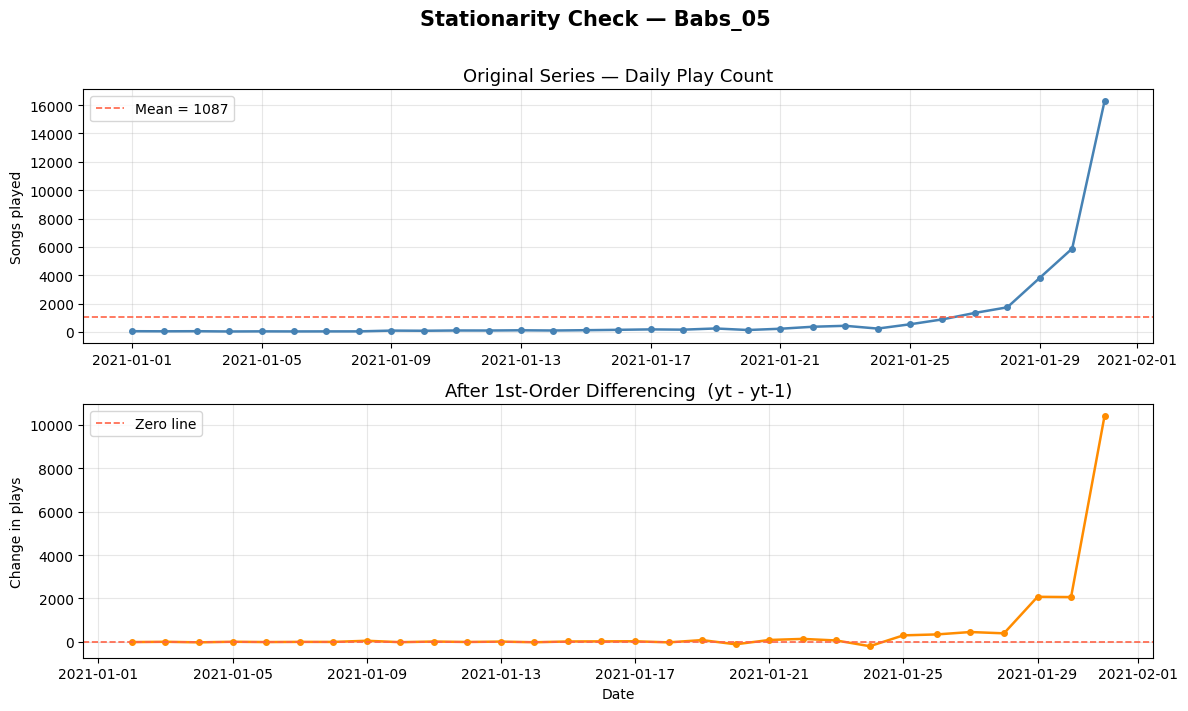

In [19]:
# ── Step 3c: Side-by-side plot — Original vs Differenced ─────────────────────

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

# Top plot: original series
axes[0].plot(ts.index, ts.values, color='steelblue',
             marker='o', markersize=4, linewidth=1.8)
axes[0].axhline(ts.mean(), color='tomato', linestyle='--',
                linewidth=1.2, label=f'Mean = {ts.mean():.0f}')
axes[0].set_title('Original Series — Daily Play Count', fontsize=13)
axes[0].set_ylabel('Songs played')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom plot: differenced series
ts_diff_plot = ts.diff().dropna()
axes[1].plot(ts_diff_plot.index, ts_diff_plot.values, color='darkorange',
             marker='o', markersize=4, linewidth=1.8)
axes[1].axhline(0, color='tomato', linestyle='--', linewidth=1.2, label='Zero line')
axes[1].set_title('After 1st-Order Differencing  (yt - yt-1)', fontsize=13)
axes[1].set_ylabel('Change in plays')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Stationarity Check — {user}', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

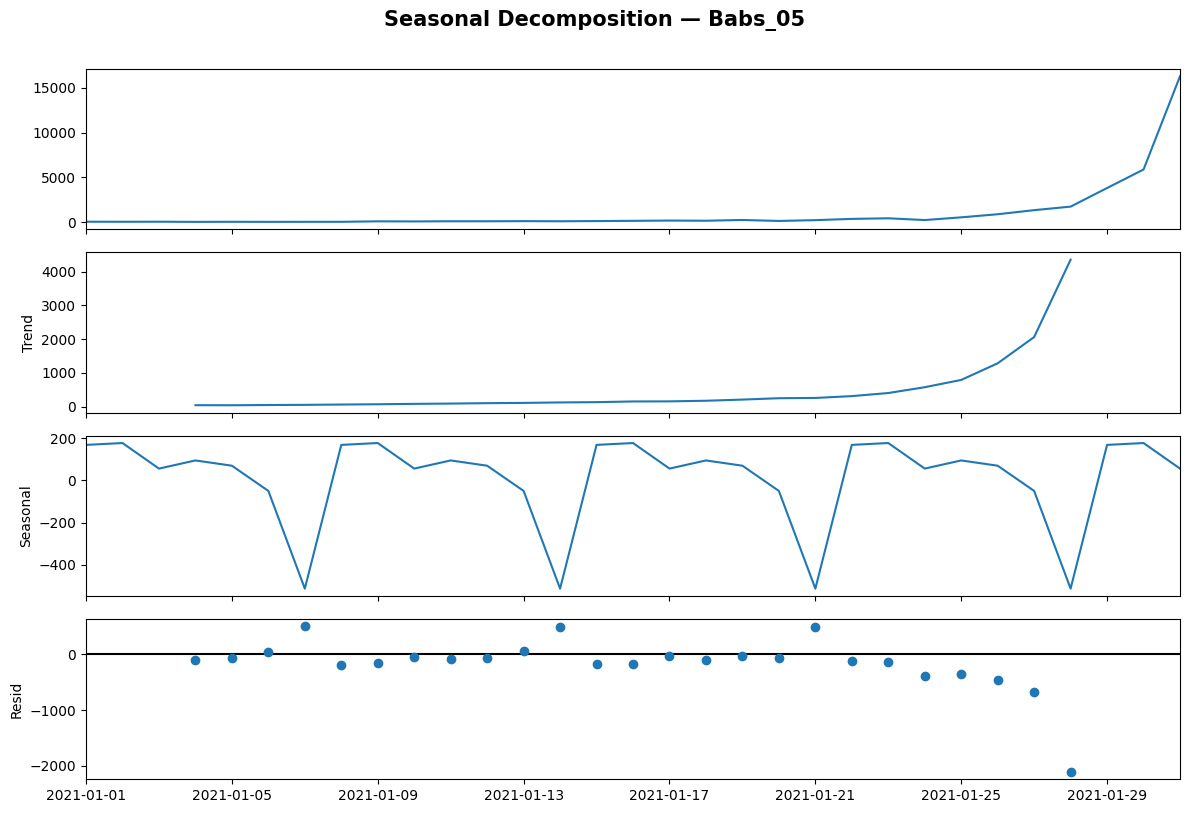

In [ ]:
# ── Step 4a: Seasonal Decomposition ──────────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose

# period=7 because listening patterns repeat weekly (Mon–Sun)
decomposition = seasonal_decompose(ts, model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle(f'Seasonal Decomposition — {user}', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

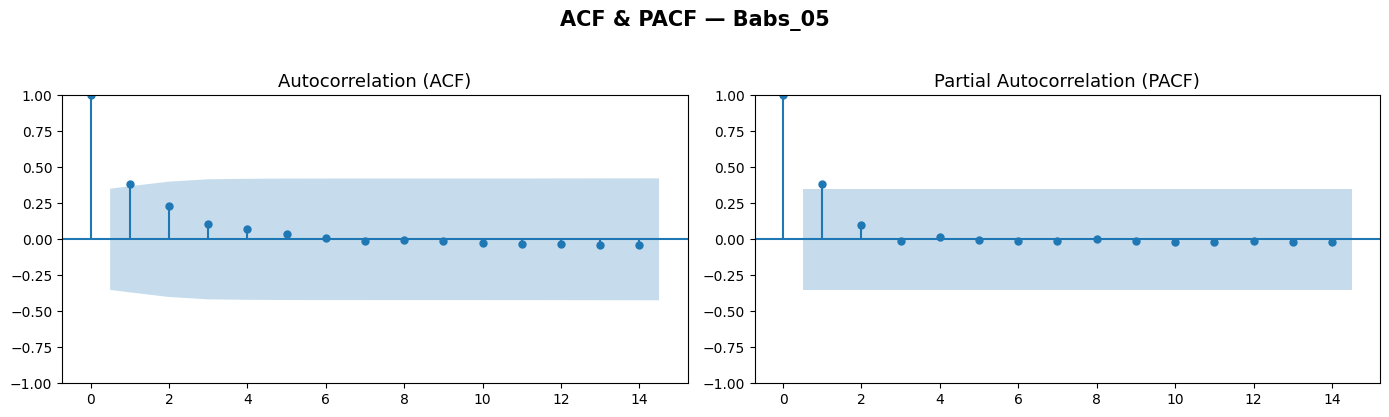

In [21]:
# ── Step 4b: ACF and PACF Plots ─────────────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# lags must be < nobs//2; with 31 days, max safe value is 14
n_lags = min(14, len(ts) // 2 - 1)

plot_acf(ts, lags=n_lags, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)', fontsize=13)

plot_pacf(ts, lags=n_lags, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (PACF)', fontsize=13)

plt.suptitle(f'ACF & PACF — {user}', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

Training days : 24  (2021-01-01 to 2021-01-24)
Test days     : 7   (2021-01-25 to 2021-01-31)


/usr/local/python/3.12.13/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/python/3.12.13/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'



                                      SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                   24
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -134.359
Date:                           Sun, 22 Mar 2026   AIC                            278.718
Time:                                   10:53:31   BIC                            284.608
Sample:                               01-01-2021   HQIC                           280.280
                                    - 01-24-2021                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9761      0.100      9.777      0.000       0.780       1.172
ma.L1         -0.3563      0.419     -0.8

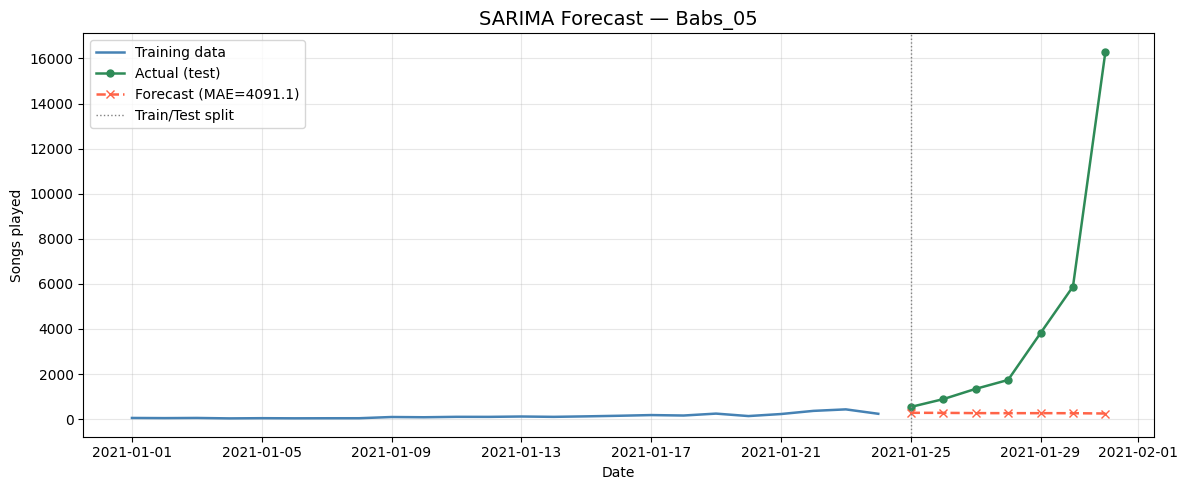

In [ ]:
# ── Step 5: SARIMA Forecasting and Evaluation ────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

# ── Train/Test Split (chronological, 80/20) ──
split = int(len(ts) * 0.8)
train, test = ts[:split], ts[split:]

print(f"Training days : {len(train)}  ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test days     : {len(test)}   ({test.index[0].date()} to {test.index[-1].date()})")

# ── Fit SARIMA model ──
# We feed the ORIGINAL series (ts) — SARIMA handles differencing internally
# via the 'd' parameter we determined from the ADF test.
#   order=(1, d, 1)          → 1 AR lag, d differencing, 1 MA lag
#   seasonal_order=(1,0,1,7) → weekly seasonality (s=7)
print(f"\nUsing d = {d} (from ADF stationarity test)")
model = SARIMAX(train, order=(1, d, 1), seasonal_order=(1, 0, 1, 7))
result = model.fit(disp=False)

print("\n", result.summary())

# ── Forecast the test period ──
forecast = result.forecast(steps=len(test))

# ── Evaluate with MAE ──
mae = mean_absolute_error(test, forecast)
print(f"\nMean Absolute Error (MAE): {mae:.2f} plays/day")

# ── Plot: Training + Actual vs Forecast ──
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train.index, train.values, color='steelblue', linewidth=1.8,
        label='Training data')
ax.plot(test.index, test.values, color='seagreen', linewidth=1.8,
        marker='o', markersize=5, label='Actual (test)')
ax.plot(forecast.index, forecast.values, color='tomato', linewidth=1.8,
        marker='x', markersize=6, linestyle='--', label=f'Forecast (MAE={mae:.1f})')

ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1, label='Train/Test split')
ax.set_title(f'SARIMA(1,{d},1)(1,0,1,7) Forecast — {user}', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Songs played')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()